<a href="https://colab.research.google.com/github/luisasoto12/Proyecto-modelos/blob/main/04-Modelo_con_preprocesado_con_Lightgbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cargar datos**

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
from sklearn.impute import SimpleImputer

In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = '.'

In [ ]:
!kaggle competitions download -c udea-ai-4-eng-20252-pruebas-saber-pro-colombia

  0% 0.00/29.9M [00:00<?, ?B/s]
100% 29.9M/29.9M [00:00<00:00, 1.46GB/s]


In [ ]:
!unzip udea-ai-4-eng-20252-pruebas-saber-pro-colombia.zip

Archive:  udea-ai-4-eng-20252-pruebas-saber-pro-colombia.zip
  inflating: submission_example.csv  
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
d = pd.read_csv("train.csv")

In [ ]:
d.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,...,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,904256,20212,ENFERMERIA,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,...,N,No,Si,Si,Postgrado,medio-alto,0.322,0.208,0.310,0.267
1,645256,20212,DERECHO,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,...,N,No,Si,No,Técnica o tecnológica incompleta,bajo,0.311,0.215,0.292,0.264
2,308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,...,N,No,No,Si,Secundaria (Bachillerato) completa,bajo,0.297,0.214,0.305,0.264
3,470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,...,N,No,Si,Si,Secundaria (Bachillerato) completa,alto,0.485,0.172,0.252,0.190
4,989032,20212,PSICOLOGIA,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,...,N,No,Si,Si,Primaria completa,medio-bajo,0.316,0.232,0.285,0.294


In [ ]:
d.E_PRGM_ACADEMICO.value_counts()

,count
E_PRGM_ACADEMICO,
DERECHO,53244
ADMINISTRACION DE EMPRESAS,51902
CONTADURIA PUBLICA,39664
PSICOLOGIA,31932
INGENIERIA INDUSTRIAL,28481
...,...
DEPORTE Y ACTIVIDADA FISICA,1
QUIMICA Y FARMACIA,1
"LICENCIATURA EN EDUCACON FISICA, RECREACION Y DEPORTES",1


In [ ]:
d[["E_PRGM_ACADEMICO", "E_PRGM_DEPARTAMENTO"]].value_counts()

E_PRGM_ACADEMICO                       E_PRGM_DEPARTAMENTO
ADMINISTRACION DE EMPRESAS             BOGOTÁ                 21468
ADMINISTRACIÓN DE EMPRESAS             BOGOTÁ                 19639
DERECHO                                BOGOTÁ                 13051
PSICOLOGIA                             BOGOTÁ                 12668
PSICOLOGÍA                             BOGOTÁ                 12293
                                                              ...  
LICENCIATURA EN PEDAGOGIA REEDUCATIVA  CALDAS                     1
SALUD OCUPACIONAL                      SANTANDER                  1
                                       PUTUMAYO                   1
CIENCIAS DE LA COMPUTACION             BOGOTÁ                     1
ADMINISTRACION DE COMERCIO EXTERIOR    BOLIVAR                    1
Name: count, Length: 2370, dtype: int64

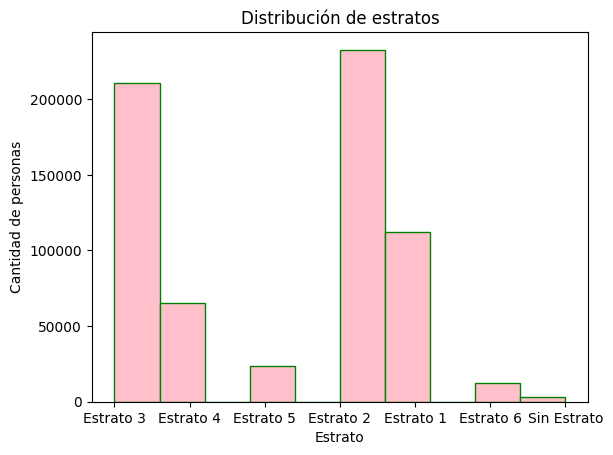

In [ ]:
plt.hist(d["F_ESTRATOVIVIENDA"].dropna(), bins=10, edgecolor="green", color="pink")
plt.title("Distribución de estratos")
plt.ylabel("Cantidad de personas")
plt.xlabel("Estrato")
plt.show()

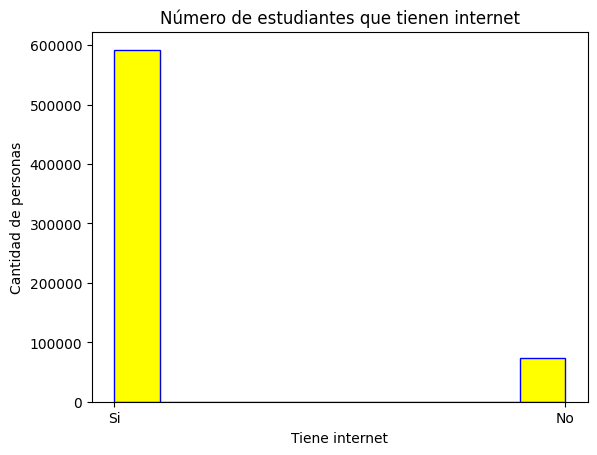

In [ ]:
plt.hist(d["F_TIENEINTERNET"].dropna(), bins=10, edgecolor="blue", color="yellow")
plt.title("Número de estudiantes que tienen internet")
plt.ylabel("Cantidad de personas")
plt.xlabel("Tiene internet")
plt.show()

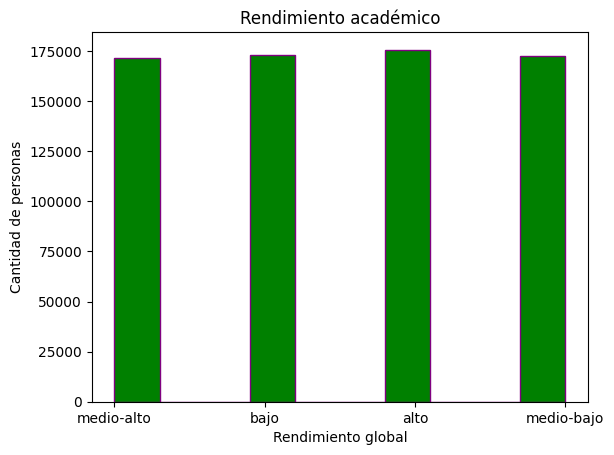

In [ ]:
plt.hist(d["RENDIMIENTO_GLOBAL"].dropna(), bins=10, edgecolor="purple", color="green")
plt.title("Rendimiento académico")
plt.ylabel("Cantidad de personas")
plt.xlabel("Rendimiento global")
plt.show()

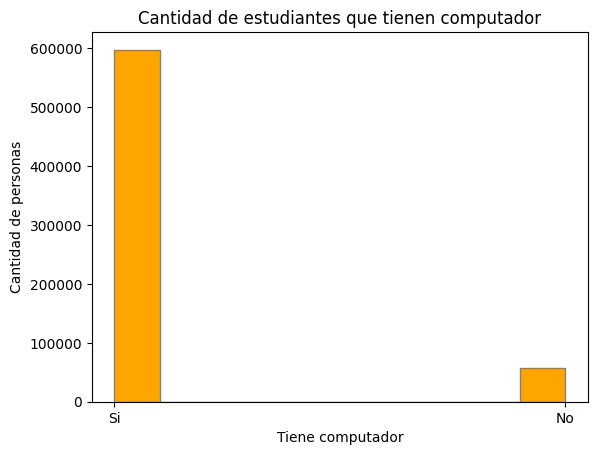

In [ ]:
plt.hist(d["F_TIENECOMPUTADOR"].dropna(), bins=10, edgecolor="grey", color="orange")
plt.title("Cantidad de estudiantes que tienen computador")
plt.ylabel("Cantidad de personas")
plt.xlabel("Tiene computador")
plt.show()

# **Limpieza**
En este paso, realizamos una función para realizar la limpieza de los archivos train.csv y test.csv, con el objetivo de organizar los datos y generar una mejor predicción

In [ ]:
def clean(data):
  data_clean = data.copy()

  #Rellenar valores faltantes para variables categóricas y numéricas
  imputer_num = SimpleImputer(strategy='mean')
  imputer_cte = SimpleImputer(strategy='most_frequent')

  num = data_clean.select_dtypes(include=['int64', 'float64']).columns
  cte = data_clean.select_dtypes(include=['object']).columns

  data_clean[num] = imputer_num.fit_transform(data_clean[num])
  data_clean[cte] = imputer_cte.fit_transform(data_clean[cte])

  #Eliminación de variables innecesarias
  columns = ['F_TIENELAVADORA', 'F_TIENEAUTOMOVIL', 'E_PRIVADO_LIBERTAD']
  data_clean = data_clean.drop(columns = [c for c in columns if c in data_clean.columns])

  #Normalización de variables categóricas
  for column in ['F_EDUCACIONMADRE', 'F_EDUCACIONPADRE', 'E_VALORMATRICULAUNIVERSIDAD']:
    data_clean[column] = data_clean[column].replace(['No sabe', 'No Aplica'], 'No aplica')

  #Convertir variable objetivo a tipo numérica
  if 'RENDIMIENTO_GLOBAL' in data_clean.columns:
    academic_performance = {'bajo': 0, 'medio-bajo': 1, 'medio-alto': 2, 'alto': 3}
    data_clean['RENDIMIENTO_GLOBAL'] = data_clean['RENDIMIENTO_GLOBAL'].map(academic_performance)

  #Nuevas variables
  data_clean['EDUCACION_PADRES'] = data_clean['F_EDUCACIONMADRE'] + '_' + data_clean['F_EDUCACIONPADRE']
  data_clean['RECURSOS_ESTUDIO'] = data_clean['F_TIENECOMPUTADOR'] + data_clean['F_TIENEINTERNET']

  #Convertir variable categórica a numérica
  if 'E_HORASSEMANATRABAJA' in data_clean.columns:
        def convertir_horas_trabajo(horas):
            if pd.isna(horas):
                return np.nan

            horas_str = str(horas). strip()

            if horas_str == '0':
                return 0
            elif horas_str == 'Menos de 10 horas':
                return 5
            elif horas_str == 'Entre 11 y 20 horas':
                return 15.5
            elif horas_str == 'Entre 21 y 30 horas':
                return 25.5
            elif horas_str == 'Más de 30 horas':
                return 35
            else:
                return np. nan

        data_clean['E_HORASSEMANATRABAJA_NUM'] = data_clean['E_HORASSEMANATRABAJA'].apply(convertir_horas_trabajo)
        data_clean = data_clean.drop(columns=['E_HORASSEMANATRABAJA'])

  return data_clean

In [ ]:
data_clean=clean(d)

#**Entrenamiento del módelo**

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
import warnings

In [ ]:
#Separación variable categórica de las variables predictoras
X = data_clean.drop(columns=["ID", "RENDIMIENTO_GLOBAL"])
y = data_clean["RENDIMIENTO_GLOBAL"]

#División del dataset en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Identificación de columnas categóricas
cat_columns = X_train.select_dtypes(include=['object']).columns. tolist()

for col in cat_columns:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

#Definir condiciones del modelo
clf = LGBMClassifier(
    n_estimators=800,
    boosting_type='gbdt',
    learning_rate=0.07,
    max_depth=7,
    min_child_samples=20,
    n_jobs=-1,
    num_leaves=31,
    reg_lambda=0.0,
    verbose=100,
    subsample=0.8,
    enable_categorical = True
)

#Entrenamiento del modelo
clf.fit(X_train, y_train, eval_set=[(X_val, y_val)])

predict = clf.predict(X_val)
accuracy = accuracy_score(y_val, predict)
print(accuracy)

[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.891128
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.280868
[LightGBM] [Debug] init for col-wise cost 0.019614 seconds, init for row-wise cost 0.112257 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048385 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 1742
[LightGBM] [Info] Number of data points in the train set: 554000, number of used feature